In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Configuracion de rutas y directorios
BASE_DIR = os.path.abspath(os.getcwd())
PROCESSED_DIR = os.path.join(BASE_DIR, "..", "data", "processed")
OUTPUT_DIR = os.path.join(BASE_DIR, "..", "output", "graphics")

# Crear carpeta de salida para las imagenes del reporte si no existe
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. Carga de los resultados consolidados del Notebook 03
ruta_proyecto = os.path.join(PROCESSED_DIR, "propuesta_tecnica_edomex_final.csv")
df_final = pd.read_csv(ruta_proyecto)

# 3. Configuracion de estilo profesional para graficas de reporte
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

print(f"--- ENTORNO LISTO ---")
print(f"Datos cargados: {len(df_final)} municipios de alta prioridad analizados.")
display(df_final.head())

--- ENTORNO LISTO ---
Datos cargados: 17 municipios de alta prioridad analizados.


,NOM_MUN,Poblacion total,DMA_NEGATI,lpd_deficit,Nivel_2025_m,Descenso_Total_m
0,Coacalco de Berriozábal,293444,-480.429914,0.004486,103.9,46.60
1,Tlalnepantla de Baz,672202,-480.429914,0.001958,77.2,22.39
2,Acambay,67872,-56.892701,0.002297,NaN,NaN
3,Aculco,49266,-56.892701,0.003164,NaN,NaN
4,Almoloya de Juárez,174587,-128.715560,0.002020,NaN,NaN


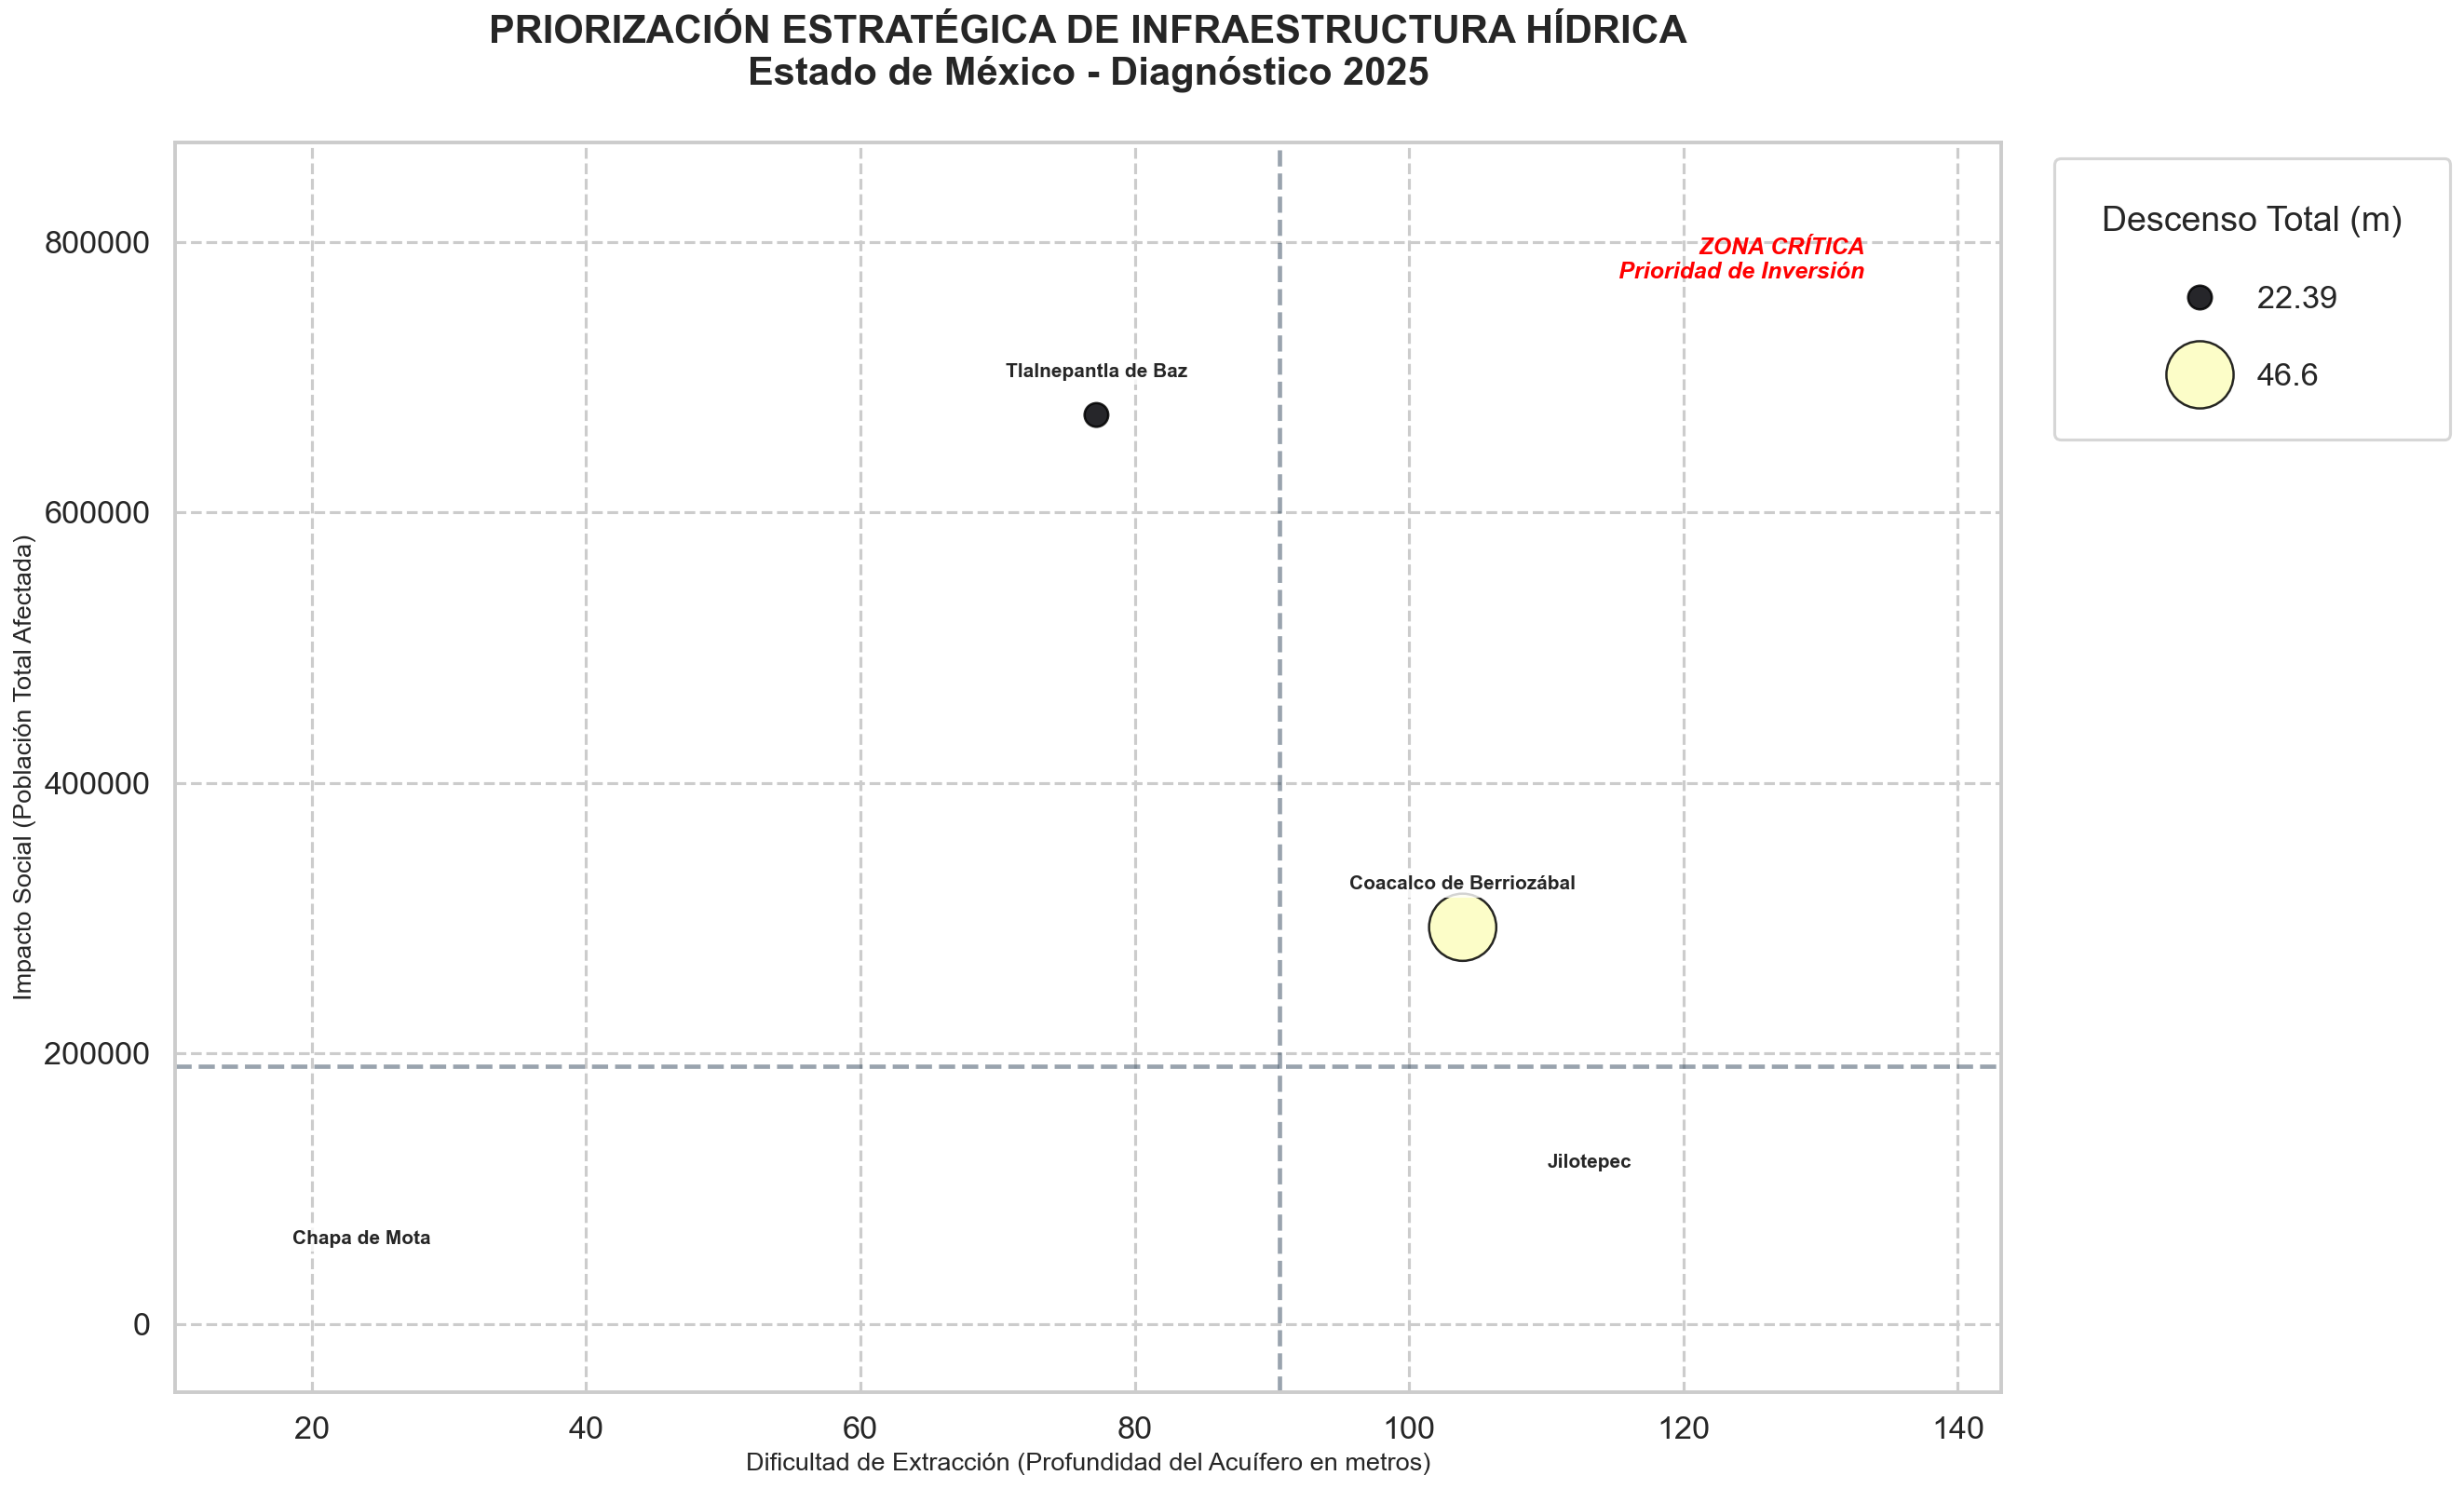

In [8]:
# 1. Limpieza de datos
df_viz = df_final.dropna(subset=['Nivel_2025_m', 'Poblacion total']).copy()

# 2. Configuración de la figura - Tamaño extra grande para claridad
plt.figure(figsize=(18, 11))
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})

# 3. Scatterplot - Círculos más pequeños y discretos
scatter = sns.scatterplot(
    data=df_viz,
    x="Nivel_2025_m",
    y="Poblacion total",
    size="Descenso_Total_m",
    hue="Descenso_Total_m",
    palette="magma",     
    sizes=(150, 1200),   # Rango reducido para evitar que se encimen
    alpha=0.85,
    edgecolor="black",
    linewidth=1.2,
    zorder=3
)

# 4. Ajuste de Cuadrantes (Mediana para equilibrio visual)
med_x = df_viz['Nivel_2025_m'].median()
med_y = df_viz['Poblacion total'].median()
plt.axvline(med_x, color='#34495e', linestyle='--', alpha=0.5, zorder=1)
plt.axhline(med_y, color='#34495e', linestyle='--', alpha=0.5, zorder=1)

# 5. LÍMITES DINÁMICOS - "Zoom Out" para dar aire
# Añadimos márgenes amplios para que las burbujas y textos no toquen los bordes
plt.xlim(10, df_viz['Nivel_2025_m'].max() + 30)
plt.ylim(-50000, df_viz['Poblacion total'].max() * 1.3)

# 6. ETIQUETADO DE MUNICIPIOS - Posicionamiento más limpio
for i in range(df_viz.shape[0]):
    x = df_viz.iloc[i]['Nivel_2025_m']
    y = df_viz.iloc[i]['Poblacion total']
    name = df_viz.iloc[i]['NOM_MUN']
    
    # Colocamos el nombre con un desplazamiento vertical proporcional al tamaño del gráfico
    plt.text(x, y + 25000, name, fontsize=10, weight='bold', 
             ha='center', va='bottom', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# 7. TÍTULOS Y ANOTACIÓN DE ZONA CRÍTICA
plt.title("PRIORIZACIÓN ESTRATÉGICA DE INFRAESTRUCTURA HÍDRICA\nEstado de México - Diagnóstico 2025", 
          fontsize=20, pad=30, weight='bold')
plt.xlabel("Dificultad de Extracción (Profundidad del Acuífero en metros)", fontsize=13)
plt.ylabel("Impacto Social (Población Total Afectada)", fontsize=13)

# Anotación en el cuadrante superior derecho
plt.text(df_viz['Nivel_2025_m'].max() + 20, df_viz['Poblacion total'].max() * 1.15, 
         "ZONA CRÍTICA\nPrioridad de Inversión", 
         color='red', fontsize=12, weight='bold', ha='right', fontstyle='italic')

# 8. LEYENDA - Ubicada estratégicamente fuera del recuadro
plt.legend(title="Descenso Total (m)", bbox_to_anchor=(1.02, 1), loc='upper left', 
           frameon=True, borderpad=1.5, labelspacing=1.5)

plt.tight_layout()

# 9. Exportación en alta calidad
plt.savefig(os.path.join(OUTPUT_DIR, "matriz_priorizacion_ampliada.png"), bbox_inches='tight', dpi=300)
plt.show()

Grafica 1 guardada en: reporte_grafico/01_matriz_priorizacion_ods6.png


<Figure size 2700x1650 with 0 Axes>

<Figure size 1800x1350 with 0 Axes>

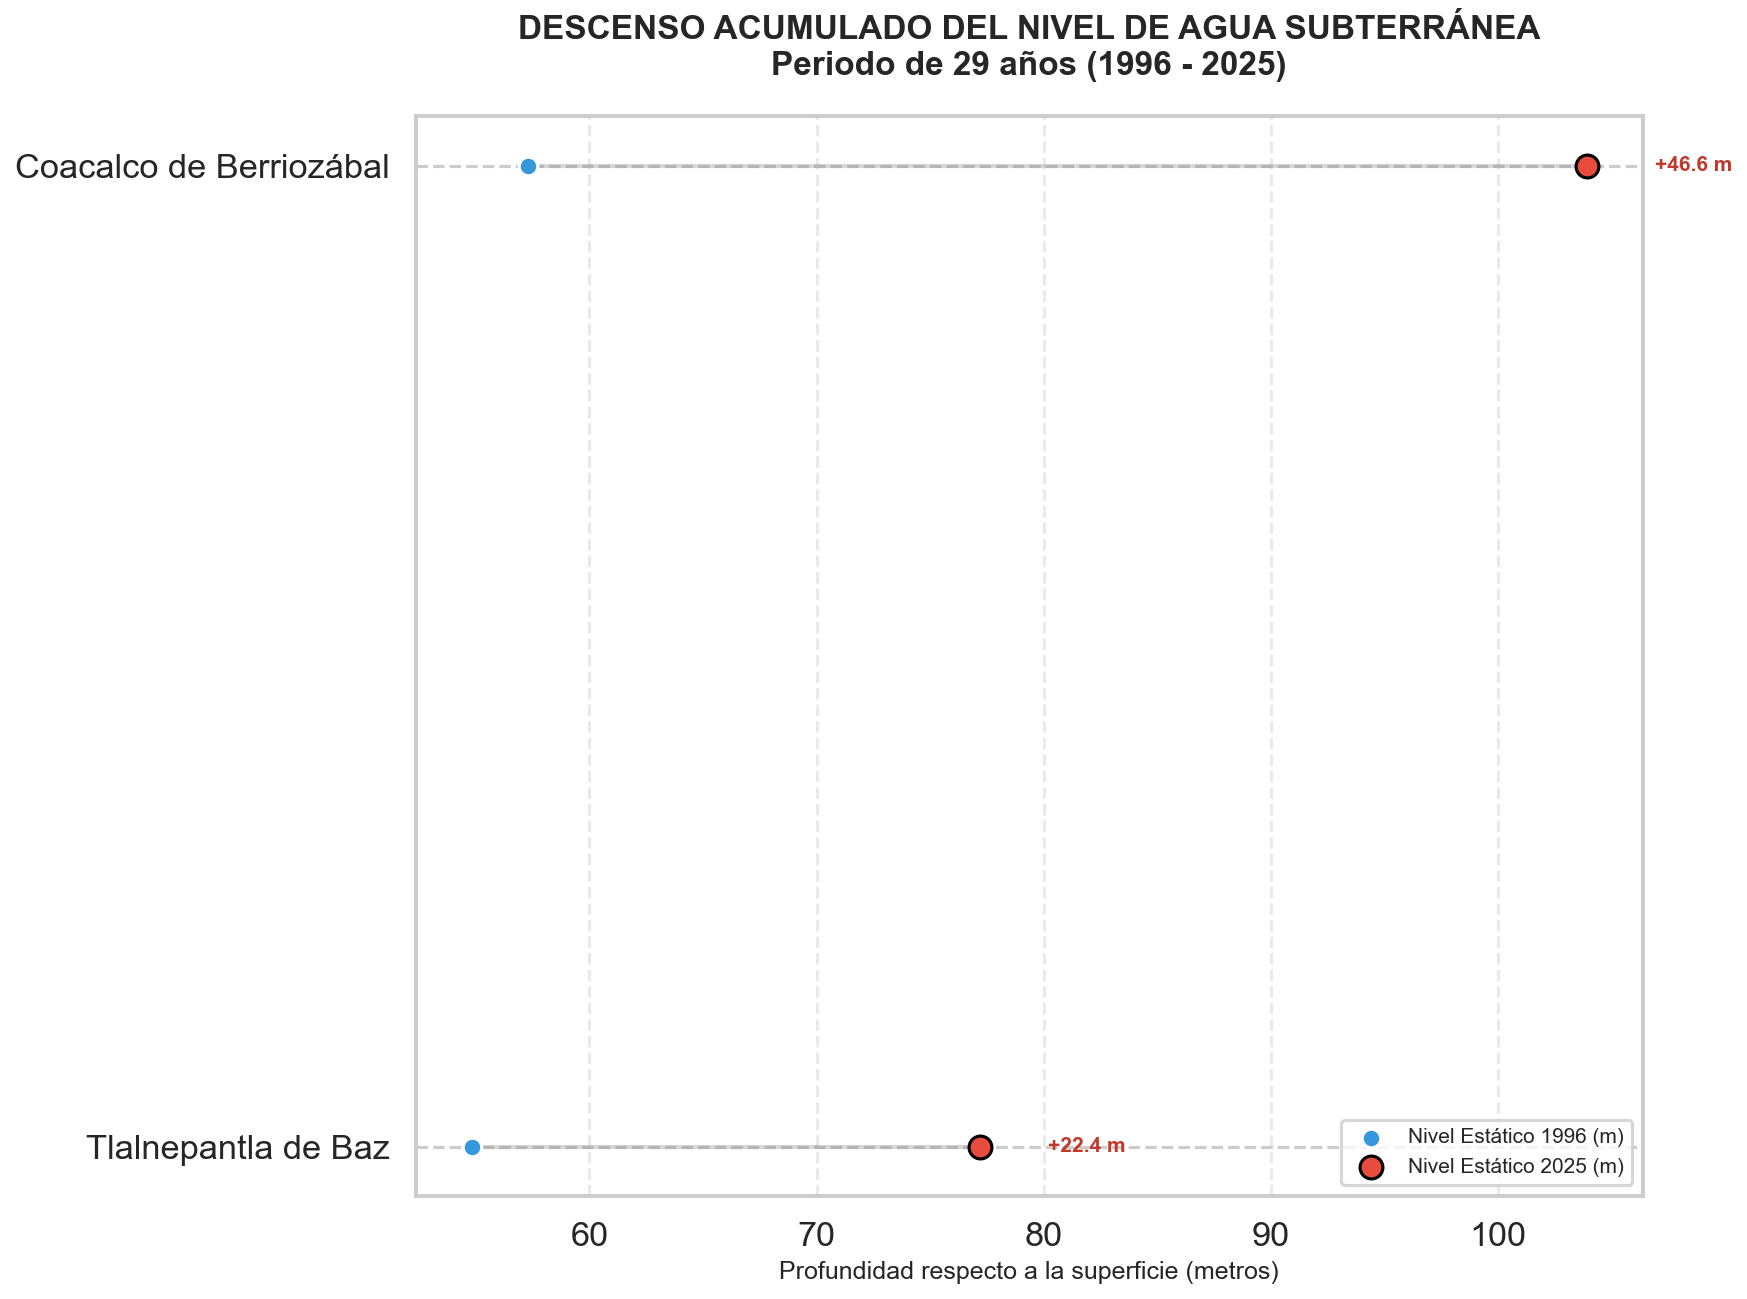

In [10]:
# 1. Definir la carpeta de salida
output_folder = "reporte_grafico"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# 2. Guardar la Matriz de Priorización (Burbujas)
plt.figure(figsize=(18, 11))
# ... (aquí va tu código de la Celda 2 de burbujas) ...
plt.savefig(os.path.join(output_folder, "01_matriz_priorizacion_ods6.png"), dpi=300, bbox_inches='tight')
print(f"Grafica 1 guardada en: {output_folder}/01_matriz_priorizacion_ods6.png")

# 3. Guardar el Gráfico de Lollipop (Descenso)
plt.figure(figsize=(12, 9))

# 1. Preparar datos: Ordenamos por el mayor descenso para que la grafica sea legible
df_lollipop = df_final.dropna(subset=['Nivel_2025_m', 'Descenso_Total_m']).copy()
df_lollipop['Nivel_1996'] = df_lollipop['Nivel_2025_m'] - df_lollipop['Descenso_Total_m']
df_lollipop = df_lollipop.sort_values(by='Descenso_Total_m', ascending=True)

# 2. Configuración de la figura
plt.figure(figsize=(12, 9))

# 3. Dibujar las líneas (el "palo" de la paleta) que une 1996 con 2025
plt.hlines(y=df_lollipop['NOM_MUN'], xmin=df_lollipop['Nivel_1996'], 
           xmax=df_lollipop['Nivel_2025_m'], color='grey', alpha=0.3, linewidth=2)

# 4. Dibujar los puntos extremos
# Punto 1996 (Nivel inicial)
plt.scatter(df_lollipop['Nivel_1996'], df_lollipop['NOM_MUN'], 
            color='#3498db', s=80, label='Nivel Estático 1996 (m)', zorder=3, edgecolor='white')

# Punto 2025 (Nivel actual)
plt.scatter(df_lollipop['Nivel_2025_m'], df_lollipop['NOM_MUN'], 
            color='#e74c3c', s=120, label='Nivel Estático 2025 (m)', zorder=3, edgecolor='black')

# 5. Añadir el valor del descenso al final de cada línea
for i, row in df_lollipop.iterrows():
    plt.text(row['Nivel_2025_m'] + 3, row['NOM_MUN'], f"+{row['Descenso_Total_m']:.1f} m", 
             va='center', color='#c0392b', weight='bold', fontsize=10)

# 6. Estética y títulos
plt.title("DESCENSO ACUMULADO DEL NIVEL DE AGUA SUBTERRÁNEA\nPeriodo de 29 años (1996 - 2025)", 
          fontsize=16, pad=20, weight='bold')
plt.xlabel("Profundidad respecto a la superficie (metros)", fontsize=12)
plt.ylabel("") # Quitamos el nombre del eje Y porque los municipios ya son claros
plt.legend(loc='lower right', frameon=True, fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

# 7. Guardar resultado
plt.savefig(os.path.join(OUTPUT_DIR, "evolucion_niveles_historico.png"), dpi=300)
plt.show()